In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
import gensim
import warnings

warnings.filterwarnings("ignore")

## DATA PREPROCESING

In [2]:
train=pd.read_csv("data train test validate/train.txt",sep=';',names=["text","emotion"])
test=pd.read_csv("data train test validate/test.txt",sep=";",names=["text","emotion"])

In [3]:
train.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [4]:
test.head()

,text,emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [5]:
# check for missing values
train.isnull().sum()

text       0
emotion    0
dtype: int64

In [6]:
test.isnull().sum()

text       0
emotion    0
dtype: int64

In [7]:
# checking for duplicate values 
print(train.isnull().sum())
print(test.isnull().sum())

text       0
emotion    0
dtype: int64
text       0
emotion    0
dtype: int64


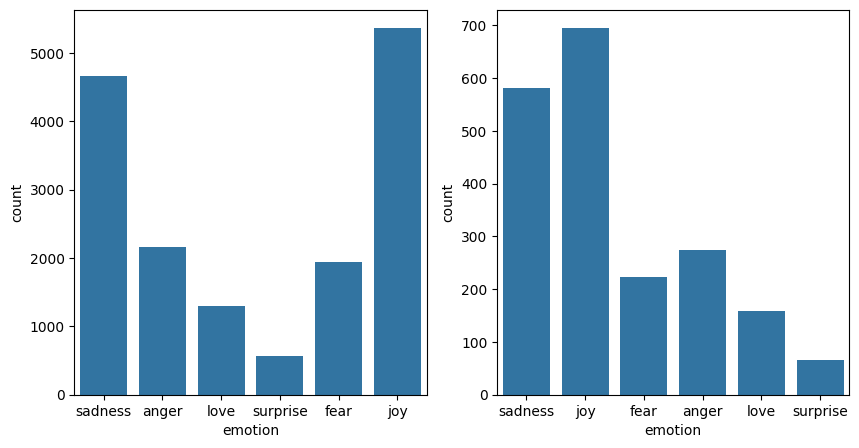

In [8]:
fig,axes=plt.subplots(1,2,figsize=(10,5))
#train count plot 
sns.countplot(x=train["emotion"],ax=axes[0])

sns.countplot(x=test["emotion"],ax=axes[1])
plt.show()

In [9]:
train["emotion"].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

In [10]:
test["emotion"].value_counts()

emotion
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

In [11]:
# info 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     2000 non-null   object
 1   emotion  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [13]:
# Basic preprocessing steps 

In [14]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import contractions

In [15]:
# stop words'Stemmer'Lemmatizer
stop_words=set(stopwords.words('english'))

ps=PorterStemmer()

lemmatizer=WordNetLemmatizer()

In [16]:
# Creating a Single Cleaning Function 

In [17]:
def clean_text(text):
    #lower_case
    text=text.lower()

    # contractions 
    text=contractions.fix(text)
    #removing URL
    text=re.sub(r'http\S+','',text)
    
    # remove punctuation and number 
    text=re.sub(r'[^a-zA-Z\s]','',text)
    
    #tokenization
    words=word_tokenize(text)
    
    #stop word removal
    words=[word for word in words if word not in stop_words]
    
    #Lemmatization
    words=[lemmatizer.lemmatize(word) for word in words]

    # join 
    return " ".join(words)

    
    

In [18]:
# train data cleaning 
train["clean_text"]=train["text"].apply(clean_text)

In [19]:
train.head(20)

,text,emotion,clean_text
0,i didnt feel humiliated,sadness,feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,anger,grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,anger,feeling grouchy
5,ive been feeling a little burdened lately wasn...,sadness,feeling little burdened lately sure
6,ive been taking or milligrams or times recomme...,surprise,taking milligram time recommended amount falle...
7,i feel as confused about life as a teenager or...,fear,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,joy,petronas year feel petronas performed well mad...
9,i feel romantic too,love,feel romantic


In [20]:
# Test Data cleaning 
test["clean_text"]=test["text"].apply(clean_text)

In [21]:
train["word_count"]=train["clean_text"].apply(lambda x:len(x.split()))

In [22]:
test.head()

,text,emotion,clean_text
0,im feeling rather rotten so im not very ambiti...,sadness,feeling rather rotten ambitious right
1,im updating my blog because i feel shitty,sadness,updating blog feel shitty
2,i never make her separate from me because i do...,sadness,never make separate ever want feel like ashamed
3,i left with my bouquet of red and yellow tulip...,joy,left bouquet red yellow tulip arm feeling slig...
4,i was feeling a little vain when i did this one,sadness,feeling little vain one


In [23]:
# Train EDA 
train["word_count"].describe()

count    16000.000000
mean         9.034500
std          5.082819
min          1.000000
25%          5.000000
50%          8.000000
75%         12.000000
max         35.000000
Name: word_count, dtype: float64

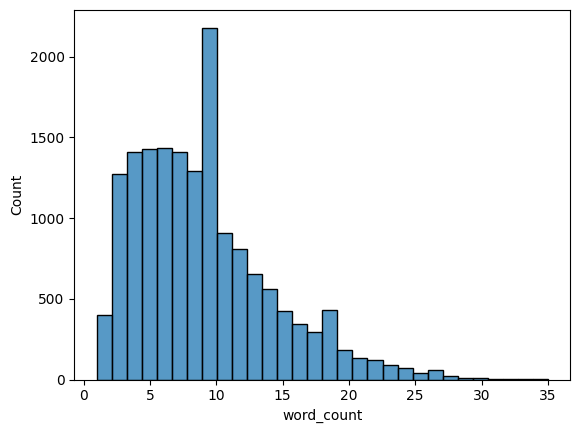

In [24]:
sns.histplot(train["word_count"],bins=30)
plt.show()

In [25]:
# Test Eda 
test["word_count"]=test["clean_text"].apply(lambda x:len(x.split()))
test["word_count"].describe()

count    2000.000000
mean        8.990500
std         5.031408
min         2.000000
25%         5.000000
50%         8.000000
75%        12.000000
max        29.000000
Name: word_count, dtype: float64

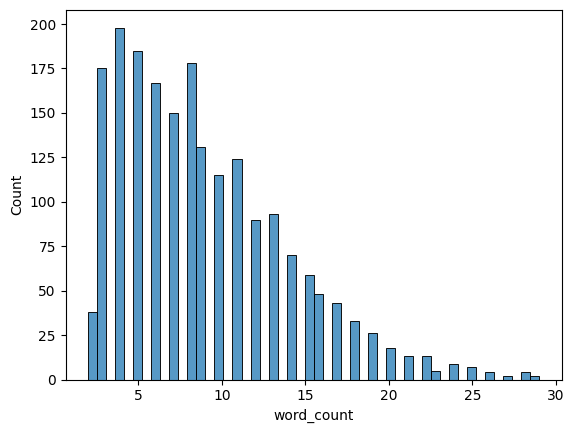

In [26]:
sns.histplot(test["word_count"],bins=50)
plt.show()

# Seprate Feature and Target (Test and Train))

In [27]:
# TRAIN SEPRATION
X_train=train["clean_text"]
y_train=train["emotion"]

In [28]:
#TEST SEPRATION
X_test=test["clean_text"]
y_test=test["emotion"]

# LABEL ENCODING OF TARGET VARIABLE

In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

y_train_en=le.fit_transform(y_train)
y_test_en=le.transform(y_test)

# FEATURE ENGINEERING 

### BAG OF WORDS 

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

In [31]:
bow=CountVectorizer()
#X_train
X_train_bow=bow.fit_transform(X_train)

# X_test 
X_test_bow=bow.transform(X_test)

In [32]:
print(len(bow.vocabulary_))
print(X_train_bow.shape)
print(bow.get_feature_names_out())
print(X_test_bow.toarray()[:10])

13390
(16000, 13390)
['aa' 'aaaaaaand' 'aaaaand' ... 'zum' 'zumba' 'zz']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [33]:
word_count=np.array(X_train_bow.sum(axis=0)).flatten()

word= bow.get_feature_names_out()

freq=pd.DataFrame({"WORD":word,"COUNT":word_count})

freq.sort_values("COUNT",ascending=False)[:20]

,WORD,COUNT
4348,feel,11506
4352,feeling,5455
6830,like,2918
11969,time,974
9502,really,942
6560,know,884
4924,get,778
7119,make,769
6891,little,736
13230,would,717


####  1.Modelling  using BOW Vectors

#### Model 1.1 : Logistic Regression (BOW)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [35]:
lr=LogisticRegression(max_iter=1000,random_state=42)

# fitting 
lr.fit(X_train_bow,y_train)

# predict on test and train 
y_train_predict_lr=lr.predict(X_train_bow)
y_test_predict_lr= lr.predict(X_test_bow)

#Accuracy 
train_accuracy_lr= accuracy_score(y_train,y_train_predict_lr)
test_accuracy_lr =accuracy_score(y_test,y_test_predict_lr)

print("Train Accuracy:",train_accuracy_lr)
print("\n")
print("Test Accuracy:",test_accuracy_lr)

print("\n")

#Confusion Matrix 
cm_lr=confusion_matrix(y_test,y_test_predict_lr)
print("Confusion_matrix")
print(cm_lr)

print("\n")

#classification Report
cr_lr=classification_report(y_test,y_test_predict_lr)
print("Classification_Report")
print(cr_lr)

Train Accuracy: 0.98375


Test Accuracy: 0.8915


Confusion_matrix
[[241   9   9   1  15   0]
 [  9 189   4   1  16   5]
 [  6   4 645  30   5   5]
 [  3   1  32 120   2   1]
 [ 14   6  11   2 547   1]
 [  1  14   8   0   2  41]]


Classification_Report
              precision    recall  f1-score   support

       anger       0.88      0.88      0.88       275
        fear       0.85      0.84      0.85       224
         joy       0.91      0.93      0.92       695
        love       0.78      0.75      0.77       159
     sadness       0.93      0.94      0.94       581
    surprise       0.77      0.62      0.69        66

    accuracy                           0.89      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.89      0.89      0.89      2000



#### Model 1.2 XGBOOST(BOW)

In [45]:
from xgboost import XGBClassifier

In [ ]:
xgb=XGBClassifier(objective='multi:softmax',num_class=len(set(y_train)),n_estimators=200,
                  max_depth=6,learning_rate=0.1,random_state=42)

In [47]:
%cd "C:\Users\Lenovo\Desktop\github projects\nlp rnn assingment"

C:\Users\Lenovo\Desktop\github projects\nlp rnn assingment


In [50]:
!git init

Initialized empty Git repository in C:/Users/Lenovo/Desktop/github projects/nlp rnn assingment/.git/


In [52]:
!git add.

git: 'add.' is not a git command. See 'git --help'.

The most similar command is
	add


### TFIDF (Vectorization)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
tfidf=TfidfVectorizer()

In [38]:
# Train Vectorizer
X_train_tfidf=tfidf.fit_transform(X_train)

#Test Vectorizer

X_test_tfidf=tfidf.transform(X_test)

#### Modelling with tfidf vectorization 

### WORD2VEC (Vectorizqation)

In [39]:
# tokenize train and test before word2vec

tokenized_train=[sentence.split() for sentence in X_train]

tokenized_test=[sentence.split() for sentence in X_test]

In [40]:
from gensim.models import Word2Vec

In [41]:
w2v=Word2Vec(sentences=tokenized_train,vector_size=100,window=5,min_count=2,workers=4)

In [42]:
w2v.wv["happy"]

array([-0.16985552,  0.39131203,  0.33349162,  0.27807072, -0.20273462,
       -0.94827914,  0.1545054 ,  0.6973288 , -0.3054776 , -0.30566564,
       -0.21701358, -0.7126994 , -0.1314127 ,  0.4886608 ,  0.15574935,
       -0.36865664,  0.21135166, -0.50656706, -0.26528013, -0.9032945 ,
        0.27569893,  0.39041302,  0.47669443, -0.17279279, -0.03382903,
        0.01752776, -0.51087826, -0.18781878, -0.43821007,  0.2358462 ,
        0.488589  ,  0.02657441,  0.21186402, -0.19808568, -0.35204342,
        0.41727388,  0.17314683, -0.49218103, -0.2587543 , -0.6725061 ,
       -0.13565938, -0.24303041, -0.29553214, -0.19896215,  0.3409172 ,
       -0.21760456, -0.54301006,  0.11566138,  0.22596684,  0.45517492,
        0.09087838, -0.43299305, -0.09069714, -0.03405474, -0.24408844,
        0.19813098,  0.42656472, -0.0776329 , -0.6343481 ,  0.27201536,
       -0.03697663, -0.04600111, -0.20065312, -0.02020038, -0.49597105,
        0.56036377, -0.20722984,  0.40027106, -0.53119236,  0.52

In [43]:
def document_vector(doc):
    words=doc.split()

    vectors= [w2v.wv[word] for word in words if word in w2v.wv]

    if len(vectors)==0:
        return np.zeros(100)
    return np.mean(vectors,axis=0)

In [44]:
X_train_w2v=np.array([document_vector(doc) for doc in X_train])

X_test_w2v=np.array([document_vector(doc) for doc in X_test])